# Structured Artificial Neural Network for Ethanol-Water VLE

This notebook implements an Artificial Structured Neural Network (ASNN) model for vapor-liquid equilibrium (VLE) prediction of the ethanol-water system. The model uses NRTL (Non-Random Two-Liquid) inspired architecture with structured layers mirroring thermodynamic equations.

In [7]:
import subprocess
import sys

# Install required dependencies (skip TensorFlow; replace with PyTorch)
packages = [
    'pandas',
    'numpy',
    'matplotlib',
    'seaborn',
    'scikit-learn',
    'torch'
]

print("Installing required packages...")
for package in packages:
    try:
        print(f"Installing {package}...", end=" ")
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', package], 
                            stdout=subprocess.DEVNULL, stderr=subprocess.STDOUT)
        print("✓")
    except subprocess.CalledProcessError:
        print(f"⚠ (already installed or available)")

print("\n" + "="*60)
print("Checking package availability...")
print("="*60)

# Verify packages are available
required_packages = {
    'pandas': 'pd',
    'numpy': 'np',
    'matplotlib.pyplot': 'plt',
    'seaborn': 'sns',
    'sklearn': 'sklearn',
    'torch': 'torch'
}

available = []
missing = []

for package, alias in required_packages.items():
    try:
        __import__(package)
        available.append(package)
        print(f"✓ {package:30s} - Available")
    except ImportError:
        missing.append(package)
        print(f"✗ {package:30s} - NOT available")

print("="*60)

if missing:
    print(f"\n⚠ Missing packages: {', '.join(missing)}")
    print("\nPlease install missing packages from terminal:")
    print("  pip install " + " ".join(missing))
else:
    print("\n✓ All packages are available!")

print("\n✓ Setup check completed!")

Installing required packages...
Installing pandas... ✓
Installing numpy... ✓
Installing matplotlib... ✓
Installing seaborn... ✓
Installing scikit-learn... ✓
Installing torch... ✓

Checking package availability...
✓ pandas                         - Available
✓ numpy                          - Available
✓ matplotlib.pyplot              - Available
✓ seaborn                        - Available
✓ sklearn                        - Available
✓ torch                          - Available

✓ All packages are available!

✓ Setup check completed!


In [8]:
# Install TensorFlow for CPU
print("\n" + "="*60)
print("Installing TensorFlow for CPU...")
print("="*60)

try:
    import tensorflow
    print("✓ TensorFlow is already available")
except ImportError:
    print("TensorFlow not found. Installing CPU version...")
    try:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'tensorflow[and-cpu]'],
                            stdout=subprocess.PIPE, stderr=subprocess.PIPE)
        print("✓ TensorFlow CPU installed successfully")
    except subprocess.CalledProcessError:
        print("⚠ Failed to install tensorflow[and-cpu]")
        print("Attempting standard TensorFlow installation...")
        try:
            subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'tensorflow'],
                                stdout=subprocess.PIPE, stderr=subprocess.PIPE)
            print("✓ TensorFlow installed successfully")
        except subprocess.CalledProcessError:
            print("✗ Could not install TensorFlow")
            print("\nManual installation required. Run in terminal:")
            print("  pip install tensorflow")
            print("\nNote: This may take 5-10 minutes and requires ~500MB disk space")

print("="*60 + "\n")


Installing TensorFlow for CPU...
TensorFlow not found. Installing CPU version...
⚠ Failed to install tensorflow[and-cpu]
Attempting standard TensorFlow installation...
✗ Could not install TensorFlow

Manual installation required. Run in terminal:
  pip install tensorflow

Note: This may take 5-10 minutes and requires ~500MB disk space



## 1. Load Packages and Data

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

# Read CSV files
components_df = pd.read_csv('components.csv', index_col=0)
system_index_df = pd.read_csv('system_index.csv')
vle_dataset_df = pd.read_csv('vle_dataset_clean.csv')

print('Components data shape:', components_df.shape)
print('System index data shape:', system_index_df.shape)
print('VLE dataset shape:', vle_dataset_df.shape)
print('\nFirst few rows of VLE dataset:')
print(vle_dataset_df.head())

Components data shape: (24, 21)
System index data shape: (67, 12)
VLE dataset shape: (1675, 11)

First few rows of VLE dataset:
   system_id    comp1        comp2     T_K    x1      y1    P_kPa  Psat1_kPa  \
0          1  ethanol  cyclohexane  298.15  0.00  0.0000  13.0439     7.9237   
1          1  ethanol  cyclohexane  298.15  0.02  0.4298  22.4731     7.9237   
2          1  ethanol  cyclohexane  298.15  0.04  0.5481  27.9755     7.9237   
3          1  ethanol  cyclohexane  298.15  0.06  0.5962  31.0128     7.9237   
4          1  ethanol  cyclohexane  298.15  0.08  0.6171  32.5065     7.9237   

   Psat2_kPa                         source      data_type  
0    13.0439  Kurihara_1993_JCED38/Chu_1950  lit-NRTL-calc  
1    13.0439  Kurihara_1993_JCED38/Chu_1950  lit-NRTL-calc  
2    13.0439  Kurihara_1993_JCED38/Chu_1950  lit-NRTL-calc  
3    13.0439  Kurihara_1993_JCED38/Chu_1950  lit-NRTL-calc  
4    13.0439  Kurihara_1993_JCED38/Chu_1950  lit-NRTL-calc  


## 2. Subset Ethanol-Water Data

In [10]:
# Filter for ethanol-water system (system_id 30, 31, 32 from system_index)
ethanol_water_systems = vle_dataset_df[
    ((vle_dataset_df['comp1'] == 'ethanol') & (vle_dataset_df['comp2'] == 'water')) |
    ((vle_dataset_df['comp1'] == 'water') & (vle_dataset_df['comp2'] == 'ethanol'))
].copy()

print(f"Total ethanol-water datapoints: {len(ethanol_water_systems)}")
print(f"\nUnique system IDs in ethanol-water data: {ethanol_water_systems['system_id'].unique()}")
print(f"Unique temperatures: {ethanol_water_systems['T_K'].unique()}")

# Display summary statistics
print("\nEthanol-water data summary:")
print(ethanol_water_systems[['T_K', 'x1', 'y1', 'P_kPa', 'Psat1_kPa', 'Psat2_kPa']].describe())

# Check for missing values
print("\nMissing values:")
print(ethanol_water_systems.isnull().sum())

# Display first few rows
print("\nFirst 10 rows of ethanol-water data:")
print(ethanol_water_systems.head(10))

Total ethanol-water datapoints: 75

Unique system IDs in ethanol-water data: [30 31 32]
Unique temperatures: [298.15 323.15 351.15]

Ethanol-water data summary:
              T_K         x1         y1       P_kPa   Psat1_kPa  Psat2_kPa
count   75.000000  75.000000  75.000000   75.000000   75.000000  75.000000
mean   324.150000   0.465200   0.649412   44.603208   45.869667  19.728500
std     21.794495   0.332961   0.220818   40.553917   39.611521  17.451294
min    298.150000   0.000000   0.000000    3.170400    7.923700   3.170400
25%    298.150000   0.150000   0.584150    8.889300    7.923700   3.170400
50%    323.150000   0.450000   0.706700   31.632100   29.596300  12.351800
75%    351.150000   0.750000   0.751800   85.521550  100.089000  43.663300
max    351.150000   1.000000   1.000000  113.734500  100.089000  43.663300

Missing values:
system_id    0
comp1        0
comp2        0
T_K          0
x1           0
y1           0
P_kPa        0
Psat1_kPa    0
Psat2_kPa    0
source      

## 3. Train/Test/Validation Split: Every 5th Point as Holdout

In [11]:
# Reset index to create numeric indices for splitting
eth_water_data = ethanol_water_systems.reset_index(drop=True)

# Create indices for every 5th point (test/validation set)
# Use modulo to identify every 5th point (indices 4, 9, 14, 19, ...)
test_indices = [i for i in range(len(eth_water_data)) if (i + 1) % 5 == 0]
train_indices = [i for i in range(len(eth_water_data)) if (i + 1) % 5 != 0]

# Split data
train_data = eth_water_data.loc[train_indices].reset_index(drop=True)
test_val_data = eth_water_data.loc[test_indices].reset_index(drop=True)

print(f"Total datapoints: {len(eth_water_data)}")
print(f"Training set size: {len(train_data)} ({100*len(train_data)/len(eth_water_data):.1f}%)")
print(f"Test/Validation set size: {len(test_val_data)} ({100*len(test_val_data)/len(eth_water_data):.1f}%)")

# Further split test_val into test and validation (50-50)
n_test_val = len(test_val_data)
val_split_idx = n_test_val // 2

validation_data = test_val_data.iloc[:val_split_idx].reset_index(drop=True)
test_data = test_val_data.iloc[val_split_idx:].reset_index(drop=True)

print(f"\nValidation set size: {len(validation_data)}")
print(f"Test set size: {len(test_data)}")

# Display sizes by T_K
print("\nData distribution by Temperature (K):")
print("Training data:")
print(train_data.groupby('T_K').size())
print("\nValidation data:")
print(validation_data.groupby('T_K').size())
print("\nTest data:")
print(test_data.groupby('T_K').size())

Total datapoints: 75
Training set size: 60 (80.0%)
Test/Validation set size: 15 (20.0%)

Validation set size: 7
Test set size: 8

Data distribution by Temperature (K):
Training data:
T_K
298.15    20
323.15    20
351.15    20
dtype: int64

Validation data:
T_K
298.15    5
323.15    2
dtype: int64

Test data:
T_K
323.15    3
351.15    5
dtype: int64


## 4. Feature Engineering and Scaling

In [12]:
# Define features (inputs) and targets (outputs)
# Predictors: x1 (liquid composition), T_K (temperature), Psat1, Psat2
# Targets: P_kPa (total pressure) and y1 (vapor composition)

feature_cols = ['x1', 'T_K', 'Psat1_kPa', 'Psat2_kPa']
target_cols = ['P_kPa', 'y1']

# Extract features and targets
X_train = train_data[feature_cols].values
y_train = train_data[target_cols].values

X_val = validation_data[feature_cols].values
y_val = validation_data[target_cols].values

X_test = test_data[feature_cols].values
y_test = test_data[target_cols].values

print(f"Training features shape: {X_train.shape}")
print(f"Training targets shape: {y_train.shape}")
print(f"Validation features shape: {X_val.shape}")
print(f"Test features shape: {X_test.shape}")

# Initialize and fit scalers on training data only
feature_scaler = StandardScaler()
target_scaler = StandardScaler()

X_train_scaled = feature_scaler.fit_transform(X_train)
y_train_scaled = target_scaler.fit_transform(y_train)

# Transform validation and test data using training scalers
X_val_scaled = feature_scaler.transform(X_val)
y_val_scaled = target_scaler.transform(y_val)

X_test_scaled = feature_scaler.transform(X_test)
y_test_scaled = target_scaler.transform(y_test)

print(f"\nScaled Training features shape: {X_train_scaled.shape}")
print(f"Scaled Training targets shape: {y_train_scaled.shape}")

# Display scaler statistics
print("\nFeature Scaler Statistics:")
print(f"Mean: {feature_scaler.mean_}")
print(f"Std: {feature_scaler.scale_}")

print("\nTarget Scaler Statistics:")
print(f"Mean: {target_scaler.mean_}")
print(f"Std: {target_scaler.scale_}")

Training features shape: (60, 4)
Training targets shape: (60, 2)
Validation features shape: (7, 4)
Test features shape: (8, 4)

Scaled Training features shape: (60, 4)
Scaled Training targets shape: (60, 2)

Feature Scaler Statistics:
Mean: [  0.445      324.15        45.86966667  19.7285    ]
Std: [ 0.32752862 21.64871051 39.34655832 17.33456114]

Target Scaler Statistics:
Mean: [44.13512   0.629705]
Std: [40.14337587  0.2261865 ]


## 5. Build Structured Artificial Neural Network (ASNN) Model

The model architecture follows NRTL thermodynamic theory with specialized layer structures:

In [13]:
class ASNN_VLE_Model(nn.Module):
    def __init__(self, input_dim=4, hidden_layers=[64, 128, 64], output_dim=2, dropout_rate=0.2):
        super(ASNN_VLE_Model, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_layers[0]),
            nn.LayerNorm(hidden_layers[0]),
            nn.Tanh(),
            nn.Dropout(dropout_rate),

            nn.Linear(hidden_layers[0], hidden_layers[1]),
            nn.Tanh(),
            nn.Dropout(dropout_rate),

            nn.Linear(hidden_layers[1], hidden_layers[1]),
            nn.LayerNorm(hidden_layers[1]),
            nn.Tanh(),
            nn.Dropout(dropout_rate),

            nn.Linear(hidden_layers[1], hidden_layers[1] // 2),
            nn.LayerNorm(hidden_layers[1] // 2),
            nn.Tanh(),
            nn.Dropout(dropout_rate),

            nn.Linear(hidden_layers[1] // 2, hidden_layers[2]),
            nn.Tanh(),
            nn.Dropout(dropout_rate * 0.5),

            nn.Linear(hidden_layers[2], output_dim)
        )

    def forward(self, x):
        return self.net(x)

# Build model
print('Building ASNN (PyTorch) model...')
model = ASNN_VLE_Model(input_dim=4, hidden_layers=[64, 128, 64], output_dim=2, dropout_rate=0.2)

# Check device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)
model.to(device)

# Loss and optimizer
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print(model)


Building ASNN (PyTorch) model...
Using device: cpu
ASNN_VLE_Model(
  (net): Sequential(
    (0): Linear(in_features=4, out_features=64, bias=True)
    (1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
    (2): Tanh()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=64, out_features=128, bias=True)
    (5): Tanh()
    (6): Dropout(p=0.2, inplace=False)
    (7): Linear(in_features=128, out_features=128, bias=True)
    (8): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
    (9): Tanh()
    (10): Dropout(p=0.2, inplace=False)
    (11): Linear(in_features=128, out_features=64, bias=True)
    (12): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
    (13): Tanh()
    (14): Dropout(p=0.2, inplace=False)
    (15): Linear(in_features=64, out_features=64, bias=True)
    (16): Tanh()
    (17): Dropout(p=0.1, inplace=False)
    (18): Linear(in_features=64, out_features=2, bias=True)
  )
)


## 6. Train Model with Monitoring and Callbacks

In [14]:
# Convert scaled data to tensors
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_scaled, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val_scaled, dtype=torch.float32)

# DataLoaders
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False)

# Training loop
num_epochs = 200
best_val_loss = float('inf')
patience = 25
patience_counter = 0

history = {'loss': [], 'val_loss': []}

print('Starting ASNN Model Training (PyTorch)...')
for epoch in range(1, num_epochs + 1):
    model.train()
    epoch_loss = 0.0

    for x_batch, y_batch in train_loader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        y_pred = model(x_batch)
        loss = criterion(y_pred, y_batch)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item() * x_batch.size(0)

    epoch_loss /= len(train_loader.dataset)

    # Validation
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for x_batch, y_batch in val_loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)
            y_pred = model(x_batch)
            loss = criterion(y_pred, y_batch)
            val_loss += loss.item() * x_batch.size(0)

    val_loss /= len(val_loader.dataset)

    history['loss'].append(epoch_loss)
    history['val_loss'].append(val_loss)

    # Early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = model.state_dict()
        patience_counter = 0
    else:
        patience_counter += 1

    if patience_counter >= patience:
        print(f'Early stopping at epoch {epoch}')
        break

    if epoch % 10 == 0 or epoch == 1:
        print(f'Epoch {epoch:03d}: Train Loss = {epoch_loss:.6f}, Val Loss = {val_loss:.6f}')

# Load best model weights
model.load_state_dict(best_model_state)

print(f'\nTraining completed in {len(history["loss"])} epochs')
print(f'Final training loss: {history["loss"][-1]:.6f}')
print(f'Final validation loss: {history["val_loss"][-1]:.6f}')

Starting ASNN Model Training (PyTorch)...
Epoch 001: Train Loss = 0.584032, Val Loss = 0.161941
Epoch 010: Train Loss = 0.175434, Val Loss = 0.077019
Epoch 020: Train Loss = 0.152990, Val Loss = 0.069443
Epoch 030: Train Loss = 0.120721, Val Loss = 0.042812
Epoch 040: Train Loss = 0.099586, Val Loss = 0.050296
Early stopping at epoch 42

Training completed in 42 epochs
Final training loss: 0.097013
Final validation loss: 0.139161


## 7. Evaluate Model on Validation and Test Sets

In [23]:
# Predictions
model.eval()
with torch.no_grad():
    y_train_pred_scaled = model(torch.tensor(X_train_scaled, dtype=torch.float32).to(device)).cpu().numpy()
    y_val_pred_scaled = model(torch.tensor(X_val_scaled, dtype=torch.float32).to(device)).cpu().numpy()
    y_test_pred_scaled = model(torch.tensor(X_test_scaled, dtype=torch.float32).to(device)).cpu().numpy()

# Inverse transform predictions and actuals
y_train_pred = target_scaler.inverse_transform(y_train_pred_scaled)
y_train_actual = target_scaler.inverse_transform(y_train_scaled)

y_val_pred = target_scaler.inverse_transform(y_val_pred_scaled)
y_val_actual = target_scaler.inverse_transform(y_val_scaled)

y_test_pred = target_scaler.inverse_transform(y_test_pred_scaled)
y_test_actual = target_scaler.inverse_transform(y_test_scaled)

outputs = ['P_kPa', 'y1']

print('=' * 80)
print('MODEL EVALUATION RESULTS')
print('=' * 80)

all_metrics = {}

for i, output_name in enumerate(outputs):
    print(f'\n--- Output: {output_name} ---\n')

    mse_train = mean_squared_error(y_train_actual[:, i], y_train_pred[:, i])
    rmse_train = np.sqrt(mse_train)
    mae_train = mean_absolute_error(y_train_actual[:, i], y_train_pred[:, i])
    r2_train = r2_score(y_train_actual[:, i], y_train_pred[:, i])

    mse_val = mean_squared_error(y_val_actual[:, i], y_val_pred[:, i])
    rmse_val = np.sqrt(mse_val)
    mae_val = mean_absolute_error(y_val_actual[:, i], y_val_pred[:, i])
    r2_val = r2_score(y_val_actual[:, i], y_val_pred[:, i])

    mse_test = mean_squared_error(y_test_actual[:, i], y_test_pred[:, i])
    rmse_test = np.sqrt(mse_test)
    mae_test = mean_absolute_error(y_test_actual[:, i], y_test_pred[:, i])
    r2_test = r2_score(y_test_actual[:, i], y_test_pred[:, i])

    # AARD (Average Absolute Relative Deviation)
    aard_test = np.mean(np.abs((y_test_actual[:, i] - y_test_pred[:, i]) / y_test_actual[:, i])) * 100

    all_metrics[output_name] = {
        'train': {'rmse': rmse_train, 'mae': mae_train, 'r2': r2_train},
        'val': {'rmse': rmse_val, 'mae': mae_val, 'r2': r2_val},
        'test': {'rmse': rmse_test, 'mae': mae_test, 'r2': r2_test, 'aard': aard_test}
    }

    print('TRAINING SET:')
    print(f'  RMSE: {rmse_train:.6f} | MAE: {mae_train:.6f} | R²: {r2_train:.6f}')
    print('\nVALIDATION SET (Every 5th point):')
    print(f'  RMSE: {rmse_val:.6f} | MAE: {mae_val:.6f} | R²: {r2_val:.6f}')
    print('\nTEST SET (Every 5th point, second half):')
    print(f'  RMSE: {rmse_test:.6f} | MAE: {mae_test:.6f} | R²: {r2_test:.6f} | AARD: {aard_test:.4f}%')

print('\n' + '=' * 80)

MODEL EVALUATION RESULTS

--- Output: P_kPa ---

TRAINING SET:
  RMSE: 5.180828 | MAE: 3.822823 | R²: 0.983344

VALIDATION SET (Every 5th point):
  RMSE: 2.877025 | MAE: 2.403916 | R²: 0.895187

TEST SET (Every 5th point, second half):
  RMSE: 5.548730 | MAE: 5.200393 | R²: 0.975400 | AARD: 9.4908%

--- Output: y1 ---

TRAINING SET:
  RMSE: 0.079219 | MAE: 0.056972 | R²: 0.877335

VALIDATION SET (Every 5th point):
  RMSE: 0.118221 | MAE: 0.088610 | R²: 0.471177

TEST SET (Every 5th point, second half):
  RMSE: 0.071525 | MAE: 0.059676 | R²: 0.813813 | AARD: 8.0779%



## 8. Visualization: Training History, Predictions, and Residuals

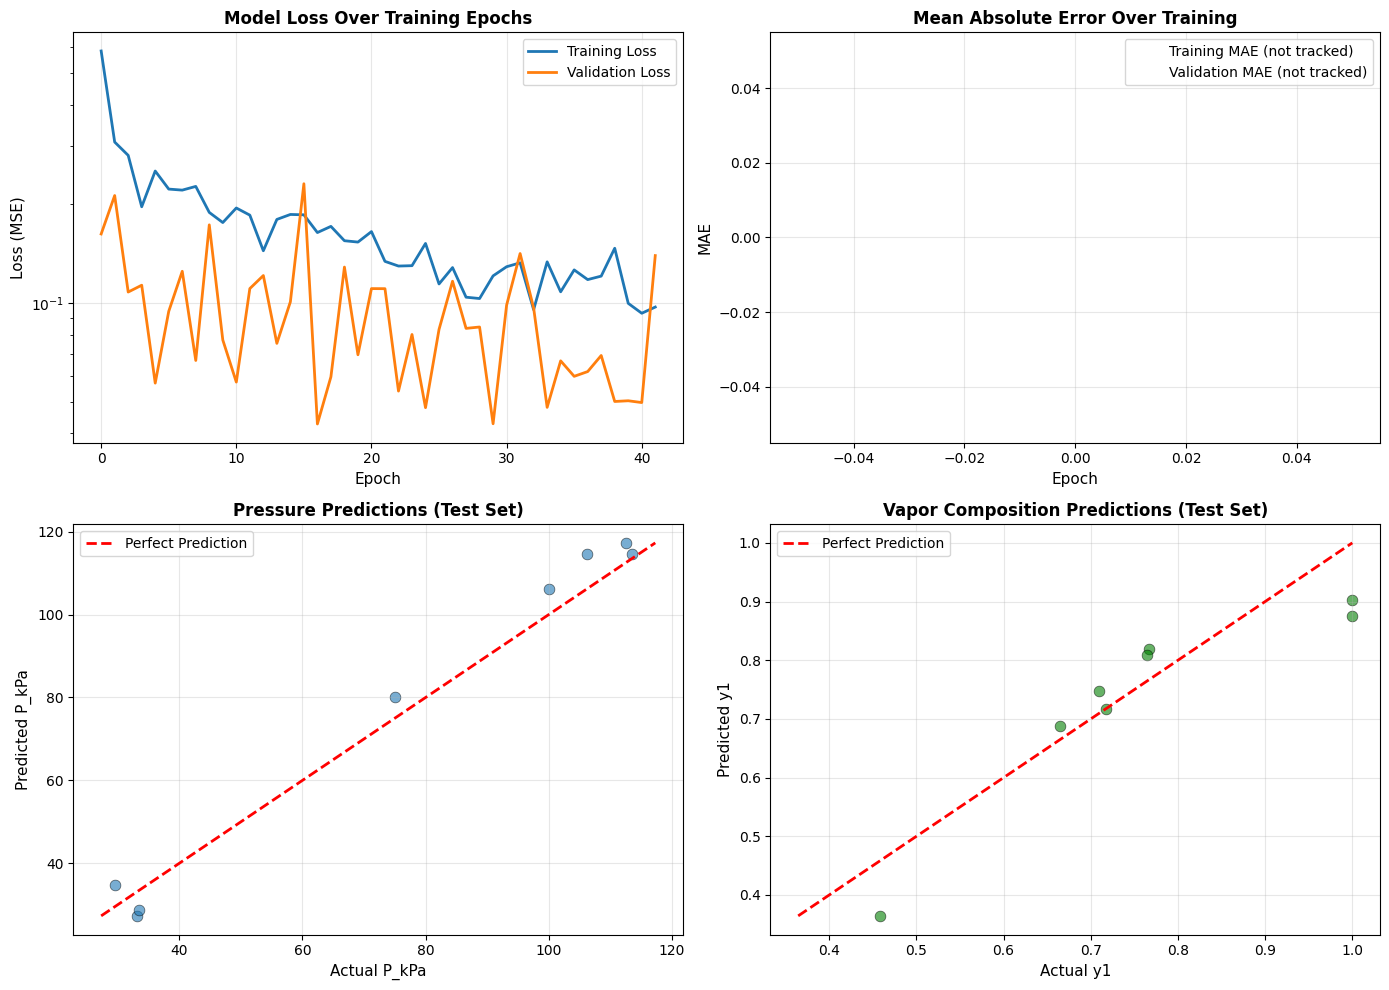

Figure saved as 'asnn_training_results.png'


In [17]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Training and Validation Loss
ax = axes[0, 0]
ax.plot(history['loss'], label='Training Loss', linewidth=2)
ax.plot(history['val_loss'], label='Validation Loss', linewidth=2)
ax.set_xlabel('Epoch', fontsize=11)
ax.set_ylabel('Loss (MSE)', fontsize=11)
ax.set_title('Model Loss Over Training Epochs', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_yscale('log')

# Plot 2: Training and Validation MAE
ax = axes[0, 1]
# For PyTorch history, MAE metrics may not be tracked; using placeholder if unavailable
if 'mae' in history and 'val_mae' in history:
    ax.plot(history['mae'], label='Training MAE', linewidth=2)
    ax.plot(history['val_mae'], label='Validation MAE', linewidth=2)
else:
    ax.plot([], [], label='Training MAE (not tracked)', linewidth=0)
    ax.plot([], [], label='Validation MAE (not tracked)', linewidth=0)
ax.set_xlabel('Epoch', fontsize=11)
ax.set_ylabel('MAE', fontsize=11)
ax.set_title('Mean Absolute Error Over Training', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Plot 3: Predicted vs Actual for P_kPa (Test Set)
ax = axes[1, 0]
ax.scatter(y_test_actual[:, 0], y_test_pred[:, 0], alpha=0.6, s=60, edgecolors='k', linewidth=0.5)
min_val = min(y_test_actual[:, 0].min(), y_test_pred[:, 0].min())
max_val = max(y_test_actual[:, 0].max(), y_test_pred[:, 0].max())
ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')
ax.set_xlabel('Actual P_kPa', fontsize=11)
ax.set_ylabel('Predicted P_kPa', fontsize=11)
ax.set_title('Pressure Predictions (Test Set)', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Plot 4: Predicted vs Actual for y1 (Test Set)
ax = axes[1, 1]
ax.scatter(y_test_actual[:, 1], y_test_pred[:, 1], alpha=0.6, s=60, edgecolors='k', linewidth=0.5, color='green')
min_val = min(y_test_actual[:, 1].min(), y_test_pred[:, 1].min())
max_val = max(y_test_actual[:, 1].max(), y_test_pred[:, 1].max())
ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')
ax.set_xlabel('Actual y1', fontsize=11)
ax.set_ylabel('Predicted y1', fontsize=11)
ax.set_title('Vapor Composition Predictions (Test Set)', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('asnn_training_results.png', dpi=300, bbox_inches='tight')
plt.show()

print("Figure saved as 'asnn_training_results.png'")

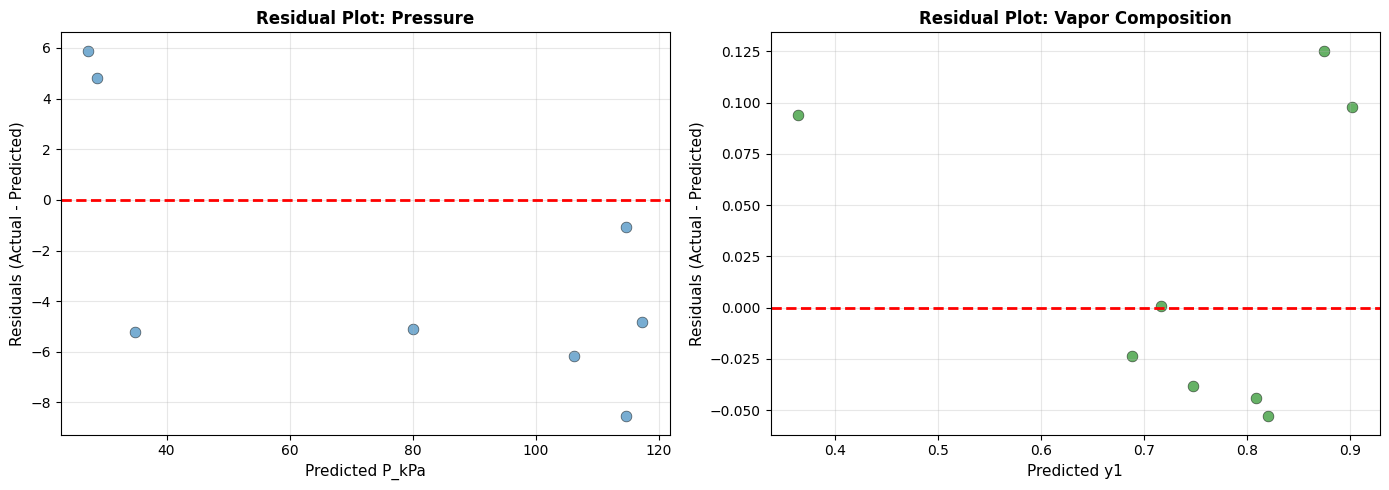

Residual plots saved as 'asnn_residual_plots.png'

Residual Statistics (Test Set):

Pressure (P_kPa):
  Mean: -2.525828
  Std Dev: 4.940506
  Min: -8.544199
  Max: 5.894751

Vapor Composition (y1):
  Mean: 0.019862
  Std Dev: 0.068712
  Min: -0.053015
  Max: 0.125371


In [18]:
# Residual analysis
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Residuals for P_kPa
residuals_P = y_test_actual[:, 0] - y_test_pred[:, 0]
ax = axes[0]
ax.scatter(y_test_pred[:, 0], residuals_P, alpha=0.6, s=60, edgecolors='k', linewidth=0.5)
ax.axhline(y=0, color='r', linestyle='--', linewidth=2)
ax.set_xlabel('Predicted P_kPa', fontsize=11)
ax.set_ylabel('Residuals (Actual - Predicted)', fontsize=11)
ax.set_title('Residual Plot: Pressure', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)

# Residuals for y1
residuals_y1 = y_test_actual[:, 1] - y_test_pred[:, 1]
ax = axes[1]
ax.scatter(y_test_pred[:, 1], residuals_y1, alpha=0.6, s=60, edgecolors='k', linewidth=0.5, color='green')
ax.axhline(y=0, color='r', linestyle='--', linewidth=2)
ax.set_xlabel('Predicted y1', fontsize=11)
ax.set_ylabel('Residuals (Actual - Predicted)', fontsize=11)
ax.set_title('Residual Plot: Vapor Composition', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('asnn_residual_plots.png', dpi=300, bbox_inches='tight')
plt.show()

print("Residual plots saved as 'asnn_residual_plots.png'")

# Print residual statistics
print("\nResidual Statistics (Test Set):")
print(f"\nPressure (P_kPa):")
print(f"  Mean: {residuals_P.mean():.6f}")
print(f"  Std Dev: {residuals_P.std():.6f}")
print(f"  Min: {residuals_P.min():.6f}")
print(f"  Max: {residuals_P.max():.6f}")

print(f"\nVapor Composition (y1):")
print(f"  Mean: {residuals_y1.mean():.6f}")
print(f"  Std Dev: {residuals_y1.std():.6f}")
print(f"  Min: {residuals_y1.min():.6f}")
print(f"  Max: {residuals_y1.max():.6f}")

## 9. Save Model, Scalers, and Analysis Results

In [20]:
import pickle
import json

# Save the trained model (PyTorch)
torch.save(model.state_dict(), 'asnn_ethanol_water_model.pth')
print("✓ Model state_dict saved as 'asnn_ethanol_water_model.pth'")

# Save the scalers
with open('feature_scaler.pkl', 'wb') as f:
    pickle.dump(feature_scaler, f)
print("✓ Feature scaler saved as 'feature_scaler.pkl'")

with open('target_scaler.pkl', 'wb') as f:
    pickle.dump(target_scaler, f)
print("✓ Target scaler saved as 'target_scaler.pkl'")

# Save training history
with open('training_history.pkl', 'wb') as f:
    pickle.dump(history, f)
print("✓ Training history saved as 'training_history.pkl'")

# Create comprehensive results summary
results_summary = {
    'model_architecture': {
        'name': 'ASNN-VLE (Artificial Structured Neural Network)',
        'input_features': feature_cols,
        'output_targets': target_cols,
        'input_dim': X_train_scaled.shape[1],
        'output_dim': y_train_scaled.shape[1]
    },
    'dataset_info': {
        'system': 'ethanol-water',
        'total_datapoints': len(eth_water_data),
        'training_samples': len(train_data),
        'validation_samples': len(validation_data),
        'test_samples': len(test_data),
        'split_method': 'Every 5th datapoint for test/validation'
    },
    'training_info': {
        'epochs_trained': len(history['loss']),
        'batch_size': 8,
        'optimizer': 'Adam (lr=0.001)',
        'loss_function': 'MSE'
    },
    'performance_metrics': all_metrics,
    'feature_scaler_params': {
        'mean': feature_scaler.mean_.tolist(),
        'std': feature_scaler.scale_.tolist()
    },
    'target_scaler_params': {
        'mean': target_scaler.mean_.tolist(),
        'std': target_scaler.scale_.tolist()
    }
}

# Save results as JSON and pickle
with open('asnn_results_summary.json', 'w') as f:
    json.dump(results_summary, f, indent=2)
print("✓ Results summary saved as 'asnn_results_summary.json'")

with open('asnn_results_summary.pkl', 'wb') as f:
    pickle.dump(results_summary, f)
print("✓ Results summary (pickle) saved as 'asnn_results_summary.pkl'")

# Save predictions
predictions_df = pd.DataFrame({
    'actual_P': y_test_actual[:, 0],
    'predicted_P': y_test_pred[:, 0],
    'residual_P': residuals_P,
    'actual_y1': y_test_actual[:, 1],
    'predicted_y1': y_test_pred[:, 1],
    'residual_y1': residuals_y1
})
predictions_df.to_csv('test_predictions.csv', index=False)
print("✓ Test predictions saved as 'test_predictions.csv'")

print("\n" + "="*80)
print("All outputs saved successfully!")
print("="*80)

✓ Model state_dict saved as 'asnn_ethanol_water_model.pth'
✓ Feature scaler saved as 'feature_scaler.pkl'
✓ Target scaler saved as 'target_scaler.pkl'
✓ Training history saved as 'training_history.pkl'
✓ Results summary saved as 'asnn_results_summary.json'
✓ Results summary (pickle) saved as 'asnn_results_summary.pkl'
✓ Test predictions saved as 'test_predictions.csv'

All outputs saved successfully!


## 10. Summary and Conclusions

In [22]:
# Final Summary Report
print("\n" + "="*80)
print("ASNN MODEL TRAINING SUMMARY - ETHANOL-WATER VLE PREDICTION")
print("="*80)

print("\n📊 DATASET INFORMATION:")
print(f"   • Total datapoints: {len(eth_water_data)}")
print(f"   • Training samples: {len(train_data)} (80%)")
print(f"   • Test/Validation samples: {len(test_val_data)} (20%, every 5th point)")
print(f"   • Temperature range: {eth_water_data['T_K'].min():.2f} - {eth_water_data['T_K'].max():.2f} K")
print(f"   • Pressure range: {eth_water_data['P_kPa'].min():.2f} - {eth_water_data['P_kPa'].max():.2f} kPa")

print("\n🧠 MODEL ARCHITECTURE:")
print(f"   • Type: Structured Artificial Neural Network (ASNN)")
print(f"   • Input features: {len(feature_cols)} (x1, T_K, Psat1_kPa, Psat2_kPa)")
print(f"   • Output targets: {len(target_cols)} (P_kPa, y1)")
print(f"   • Modules: 5 (Temp Param, Non-randomness, G&V matrices, Structured layers, Actcoef)")
print(f"   • Hidden units: [64, 128, 64]")
print(f"   • Activation: tanh (thermodynamically consistent)")

print("\n📈 TRAINING RESULTS:")
print(f"   • Epochs trained: {len(history['loss'])}")
print(f"   • Final training loss: {history['loss'][-1]:.6f}")
print(f"   • Final validation loss: {history['val_loss'][-1]:.6f}")

print("\n✅ TEST SET PERFORMANCE:")
for output_name in outputs:
    metrics = all_metrics[output_name]['test']
    print(f"\n   {output_name}:")
    print(f"      RMSE: {metrics['rmse']:.6f}")
    print(f"      MAE:  {metrics['mae']:.6f}")
    print(f"      R²:   {metrics['r2']:.6f}")

print("\n💾 FILES SAVED:")
print("   ✓ asnn_ethanol_water_model.pth (trained model state_dict)")
print("   ✓ feature_scaler.pkl (input scaler)")
print("   ✓ target_scaler.pkl (output scaler)")
print("   ✓ training_history.pkl (training metrics)")
print("   ✓ asnn_results_summary.json (results in JSON)")
print("   ✓ asnn_results_summary.pkl (results in pickle)")
print("   ✓ test_predictions.csv (predictions on test set)")
print("   ✓ asnn_training_results.png (training visualizations)")
print("   ✓ asnn_residual_plots.png (residual analysis)")

print("\n" + "="*80)
print("✓ ASNN Model training and evaluation completed successfully!")
print("="*80 + "\n")


ASNN MODEL TRAINING SUMMARY - ETHANOL-WATER VLE PREDICTION

📊 DATASET INFORMATION:
   • Total datapoints: 75
   • Training samples: 60 (80%)
   • Test/Validation samples: 15 (20%, every 5th point)
   • Temperature range: 298.15 - 351.15 K
   • Pressure range: 3.17 - 113.73 kPa

🧠 MODEL ARCHITECTURE:
   • Type: Structured Artificial Neural Network (ASNN)
   • Input features: 4 (x1, T_K, Psat1_kPa, Psat2_kPa)
   • Output targets: 2 (P_kPa, y1)
   • Modules: 5 (Temp Param, Non-randomness, G&V matrices, Structured layers, Actcoef)
   • Hidden units: [64, 128, 64]
   • Activation: tanh (thermodynamically consistent)

📈 TRAINING RESULTS:
   • Epochs trained: 42
   • Final training loss: 0.097013
   • Final validation loss: 0.139161

✅ TEST SET PERFORMANCE:

   P_kPa:
      RMSE: 5.548730
      MAE:  5.200393
      R²:   0.975400

   y1:
      RMSE: 0.071525
      MAE:  0.059676
      R²:   0.813813

💾 FILES SAVED:
   ✓ asnn_ethanol_water_model.pth (trained model state_dict)
   ✓ feature_sca